# OAI Baseline KL Labels
Extracts Kellgren–Lawrence grades from `KXR_SQ_BU00.txt` (OAI baseline X-ray semi-quantitative assessment).  
Output: `oai_labels.csv` with columns `subject_id | side | kl_grade`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Before running:** Upload `KXR_SQ_BU00.txt` to your Google Drive at:
`My Drive/Master Thesis/oai/assessments/XR Knee Semi-Quant/KXR_SQ_BU00.txt`


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DRIVE_ROOT = Path('/content/drive/MyDrive')
PROJECT    = DRIVE_ROOT / 'Master Thesis'

SRC_FILE = PROJECT / 'oai' / 'assessments' / 'XR Knee Semi-Quant' / 'KXR_SQ_BU00.txt'
OUT_DIR  = PROJECT / 'oai'
OUT_DIR.mkdir(parents=True, exist_ok=True)

assert SRC_FILE.exists(), f"File not found: {SRC_FILE}"


In [3]:

df = pd.read_csv(SRC_FILE, sep='|', dtype=str, low_memory=False)
print(f"Raw rows: {len(df):,}  |  Columns: {df.shape[1]}")
df[['ID', 'SIDE', 'READPRJ', 'V00XRKL']].head(8)

Raw rows: 16,666  |  Columns: 24


,ID,SIDE,READPRJ,V00XRKL
0,9000099,1: Right,15,2: 2
1,9000099,2: Left,15,3: 3
2,9000296,1: Right,15,2: 2
3,9000296,2: Left,15,3: 3
4,9000622,1: Right,15,1: 1
5,9000622,2: Left,15,1: 1
6,9000798,1: Right,15,1: 1
7,9000798,1: Right,37,1: 1


In [4]:


def parse_kl(val):
    if pd.isna(val):
        return np.nan
    token = val.split(':')[0].strip()
    try:
        return int(token)
    except ValueError:
        return np.nan

df['kl_grade'] = df['V00XRKL'].apply(parse_kl)

side_map = {'1': 'R', '2': 'L'}
df['side'] = df['SIDE'].str.extract(r'^(\d+):')[0].map(side_map)

df['READPRJ'] = pd.to_numeric(df['READPRJ'], errors='coerce')

print("KL parse — unique raw values sample:",
      df['V00XRKL'].value_counts().head(10).to_dict())

KL parse — unique raw values sample: {'0: 0': 8085, '1: 1': 3575, '2: 2': 3152, '3: 3': 1466, '4: 4': 314, '.: Missing Form/Incomplete Workbook': 74}


In [5]:


df15 = df[df['READPRJ'] == 15].copy()

df15 = df15.dropna(subset=['kl_grade', 'side'])
df15['kl_grade'] = df15['kl_grade'].astype(int)

df15 = df15[df15['kl_grade'].between(0, 4)]

df15 = df15.drop_duplicates(subset=['ID', 'side'])

df15['ID'] = df15['ID'].str.strip()

result = (
    df15[['ID', 'side', 'kl_grade']]
    .rename(columns={'ID': 'subject_id'})
    .sort_values(['subject_id', 'side'])
    .reset_index(drop=True)
)

print(f"Knees with valid KL: {len(result):,}")
print(f"Unique subjects:     {result['subject_id'].nunique():,}")
print("\nKL distribution:")
print(result['kl_grade'].value_counts().sort_index())

IMAGE_DIR = PROJECT / 'oai' / 'screening_images'
image_subjects = set()
for p in IMAGE_DIR.rglob('*'):
    if p.is_file() and p.suffix == '':
        parts = p.relative_to(IMAGE_DIR).parts
        if len(parts) >= 2:
            image_subjects.add(parts[1])

label_subjects = set(result['subject_id'])
matched          = label_subjects & image_subjects
unmatched_labels = label_subjects - image_subjects
unmatched_images = image_subjects - label_subjects

print(f"\nImage folders      : {len(image_subjects):,} subjects")
print(f"Label subjects     : {len(label_subjects):,}")
print(f"Matched            : {len(matched):,}")
print(f"Labels w/o image   : {len(unmatched_labels):,}")
print(f"Images w/o label   : {len(unmatched_images):,}")
if unmatched_labels:
    print(f"  Sample unmatched labels : {sorted(unmatched_labels)[:5]}")
if unmatched_images:
    print(f"  Sample unmatched images : {sorted(unmatched_images)[:5]}")


Knees with valid KL: 8,921
Unique subjects:     4,490

KL distribution:
kl_grade
0    3440
1    1588
2    2362
3    1237
4     294
Name: count, dtype: int64

Image folders      : 4,795 subjects
Label subjects     : 4,490
Matched            : 4,490
Labels w/o image   : 0
Images w/o label   : 305
  Sample unmatched images : ['9002663', '9004462', '9005905', '9005942', '9007422']


In [6]:

out_path = OUT_DIR / 'oai_labels.csv'
result.to_csv(out_path, index=False)
print(f"Saved → {out_path}")
result.head(8)

Saved → /content/drive/MyDrive/Master Thesis/oai/oai_labels.csv


,subject_id,side,kl_grade
0,9000099,L,3
1,9000099,R,2
2,9000296,L,3
3,9000296,R,2
4,9000622,L,1
5,9000622,R,1
6,9000798,L,4
7,9000798,R,1


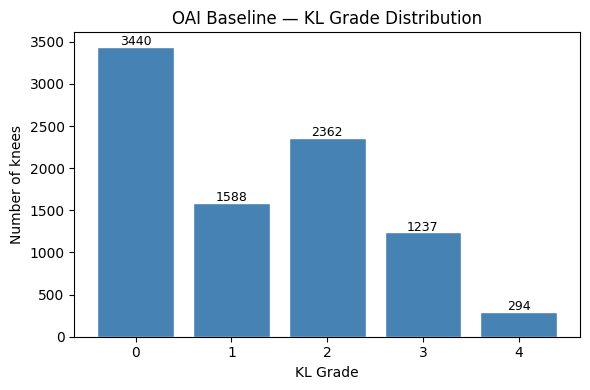

In [7]:

counts = result['kl_grade'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('KL Grade')
ax.set_ylabel('Number of knees')
ax.set_title('OAI Baseline — KL Grade Distribution')
for x, y in zip(counts.index, counts.values):
    ax.text(x, y + 20, str(y), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'oai_kl_distribution.png', dpi=150)
plt.show()